In [22]:
import os
import cv2
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [23]:
dataset_path = "Rambu/Train"

X = []
y = []

print("Membaca dataset...")

Membaca dataset...


In [24]:
for class_id in os.listdir(dataset_path):

    class_path = os.path.join(
        dataset_path,
        class_id
    )

    if not os.path.isdir(class_path):
        continue

    for image_name in os.listdir(class_path):

        image_path = os.path.join(
            class_path,
            image_name
        )

        try:

            img = cv2.imread(image_path)

            img = cv2.resize(
                img,
                (48,48)
            )

            gray = cv2.cvtColor(
                img,
                cv2.COLOR_BGR2GRAY
            )

            features = hog(
                gray,
                orientations=9,
                pixels_per_cell=(8,8),
                cells_per_block=(2,2),
                block_norm='L2-Hys'
            )

            X.append(
                features.astype(np.float32)
            )

            y.append(int(class_id))

        except:
            pass

print("Dataset berhasil dibaca")

Dataset berhasil dibaca


In [25]:
X = np.array(
    X,
    dtype=np.float32
)

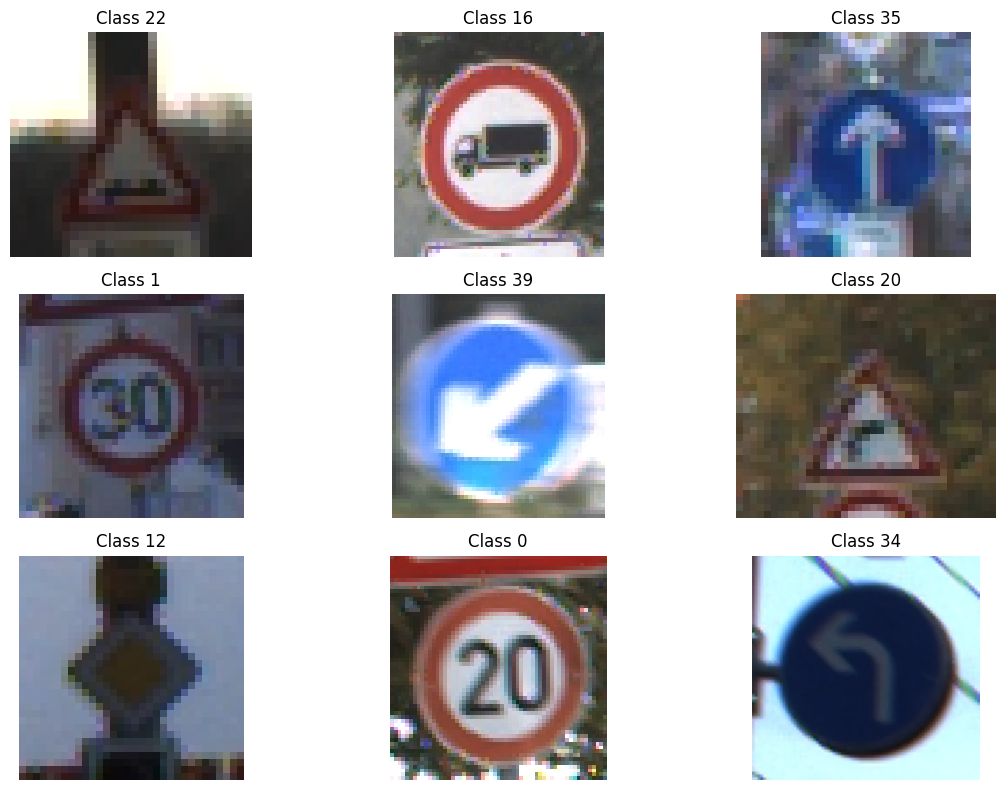

In [26]:
import random

plt.figure(figsize=(12,8))

for i in range(9):

    class_id = random.choice(os.listdir(dataset_path))

    class_path = os.path.join(
        dataset_path,
        class_id
    )

    image_name = random.choice(
        os.listdir(class_path)
    )

    image_path = os.path.join(
        class_path,
        image_name
    )

    img = cv2.imread(image_path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(f"Class {class_id}")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
print(len(X))
print(len(y))

39209
39209


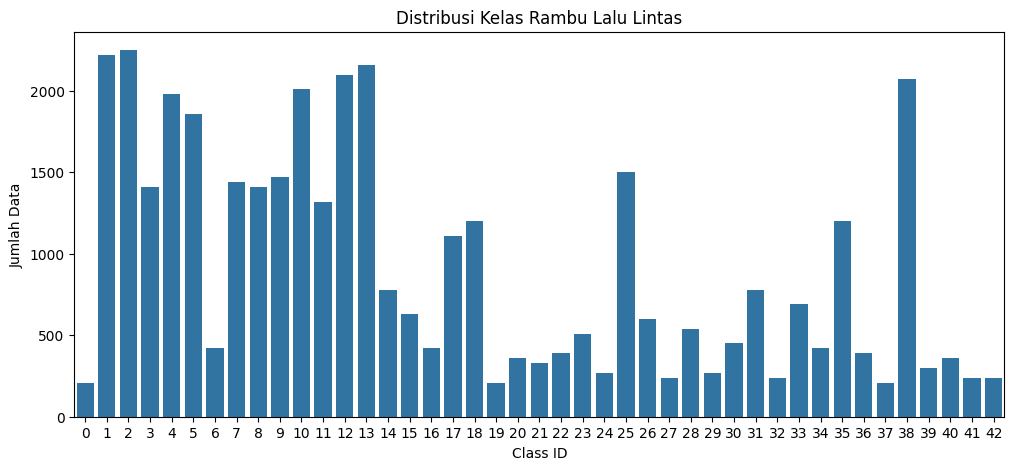

In [28]:
plt.figure(figsize=(12,5))

sns.countplot(
    x=y
)

plt.title("Distribusi Kelas Rambu Lalu Lintas")
plt.xlabel("Class ID")
plt.ylabel("Jumlah Data")

plt.show()

In [29]:
X = np.array(X)
y = np.array(y)

print("Jumlah Data :", len(X))
print("Jumlah Label :", len(y))
print("Shape X :", X.shape)
print("Shape y :", y.shape)

Jumlah Data : 39209
Jumlah Label : 39209
Shape X : (39209, 900)
Shape y : (39209,)


In [30]:
print("Jumlah Data :", len(X))
print("Jumlah Kelas :", len(np.unique(y)))
print("Label Kelas :", np.unique(y))

Jumlah Data : 39209
Jumlah Kelas : 43
Label Kelas : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data Train :", len(X_train))
print("Data Test :", len(X_test))

Data Train : 31367
Data Test : 7842


In [32]:
rf = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

print("Model berhasil dibuat")

Model berhasil dibuat


In [33]:
rf.fit(X_train, y_train)

print("Training selesai")

Training selesai


In [34]:
y_pred = rf.predict(X_test)

print("Prediksi selesai")

Prediksi selesai


In [35]:
acc = accuracy_score(y_test, y_pred)

print("Akurasi Model :", acc)

Akurasi Model : 0.9367508288701861


In [36]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.74      0.85        42
           1       0.86      0.82      0.84       444
           2       0.79      0.90      0.84       450
           3       0.93      0.90      0.92       282
           4       0.96      0.95      0.95       396
           5       0.84      0.77      0.80       372
           6       1.00      0.98      0.99        84
           7       0.89      0.91      0.90       288
           8       0.90      0.84      0.87       282
           9       0.93      0.98      0.96       294
          10       0.96      1.00      0.98       402
          11       0.85      0.95      0.90       264
          12       1.00      1.00      1.00       420
          13       1.00      1.00      1.00       432
          14       0.99      0.96      0.98       156
          15       0.98      1.00      0.99       126
          16       1.00      0.99      0.99        84
          17       1.00    

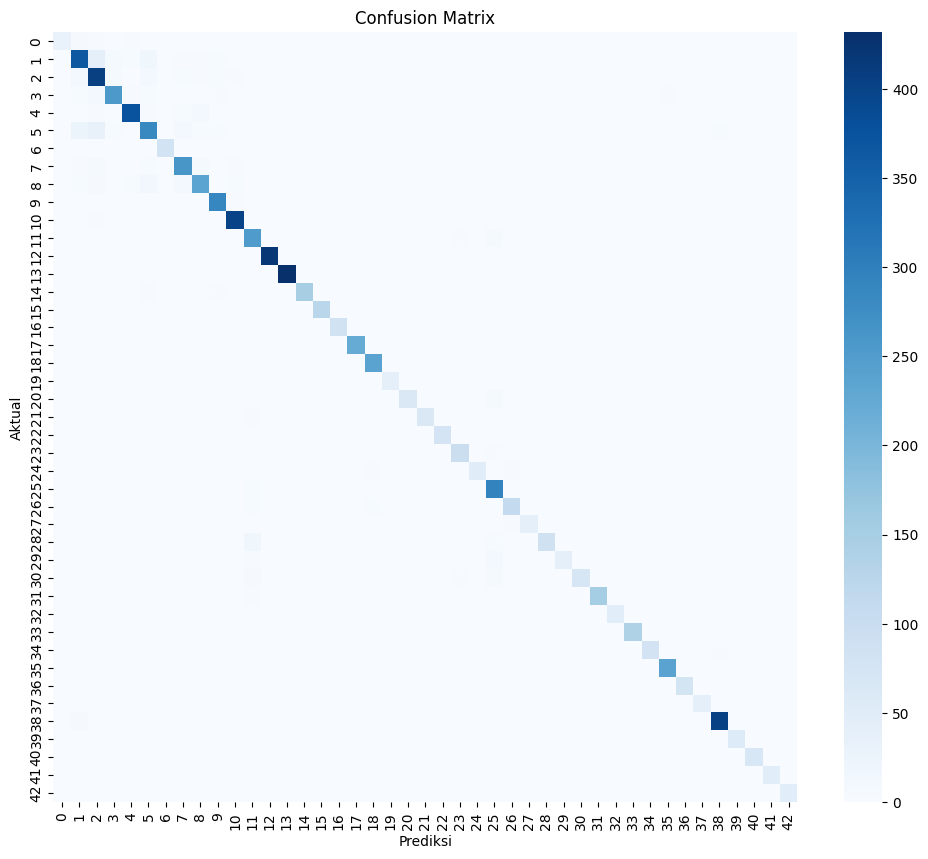

In [37]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.show()

In [38]:
print(X.shape)

(39209, 900)


In [39]:
print(len(np.unique(y)))

43


In [40]:
import joblib

joblib.dump(
    rf,
    "random_forest_gtsrb.pkl"
)

print("Model berhasil disimpan!")

Model berhasil disimpan!


In [41]:
import cv2
import joblib

from skimage.feature import hog

model = joblib.load(
    "random_forest_gtsrb.pkl"
)

img = cv2.imread(
    "rambu/Test/01546.png"
)

img = cv2.resize(
    img,
    (48,48)
)

gray = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2GRAY
)

features = hog(
    gray,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    block_norm='L2-Hys'
)

prediction = model.predict(
    [features]
)

print(prediction)

[2]


In [42]:
import os
import sklearn
import joblib

print("Sklearn:", sklearn.__version__)

size_mb = os.path.getsize(
    "random_forest_gtsrb.pkl"
)/(1024*1024)

print("Size:", size_mb, "MB")

model = joblib.load(
    "random_forest_gtsrb.pkl"
)

print(type(model))

Sklearn: 1.8.0
Size: 149.43798923492432 MB
<class 'sklearn.ensemble._forest.RandomForestClassifier'>
